In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA



### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [110]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [4]:
# Split training and test data
X = df[feature_names]
y = df['Heating Load']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    train_size= 0.7, 
    random_state = 42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [6]:
# Fit a linear regression
ols = LinearRegression().fit(X_train_scaled, y_train)

# Find test MSE
mse_ols = mean_squared_error(y_test, ols.predict(X_test_scaled))


In [7]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [8]:
lambdas = np.logspace(-4, 4, 100)

ridge_cv = RidgeCV(alphas = lambdas, cv = 10, scoring = 'neg_mean_squared_error')

ridge_cv.fit(X_train_scaled, y_train)

ridge_cv.alpha_

# Find the coefficient associated with each feature
dt = pd.DataFrame({
    'feature': feature_names,
    'OLS coefficient': list(ols.coef_),
    'Ridge coefficient': list(ridge_cv.coef_)
})

# Print table
dt

,feature,OLS coefficient,Ridge coefficient
0,Relative Compactness,-6.686924,-6.352418
1,Surface Area,-3.701472,-3.474392
2,Wall Area,0.761142,0.816587
3,Roof Area,-3.992429,-3.797180
4,Overall Height,7.216818,7.306373
5,Orientation,-0.026067,-0.025299
6,Glazing Area,2.670032,2.670852
7,Glazing Area Distribution,0.356042,0.356417


In [9]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

None of the coefficients change much with the ridge model comapred to the OLS model, there are only minimal reductions in some coefficients. This means that the penalty is not doing anything to shrink unimportant predictors.

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [10]:
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

In [11]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

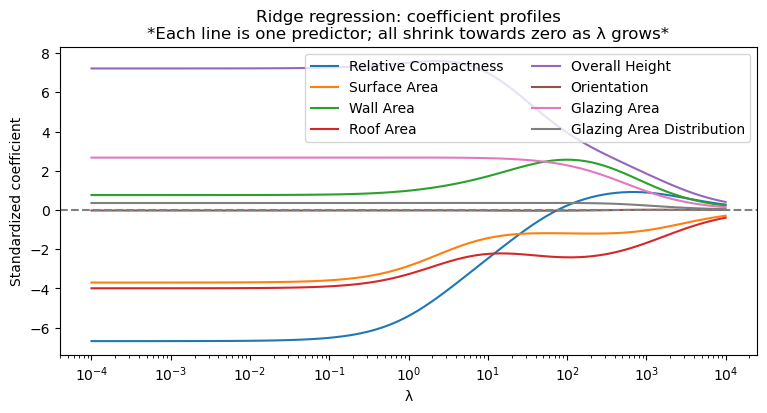

In [12]:
coefs = [Ridge(alpha=l).fit(X_train_scaled, y_train).coef_ for l in lambdas]

plt.figure(figsize=(9, 4))
for i, feature in enumerate(feature_names):
    plt.plot(lambdas, [c[i] for c in coefs], label=feature)

plt.xscale('log')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('λ')
plt.ylabel('Standardized coefficient')
plt.title('Ridge regression: coefficient profiles\n*Each line is one predictor; all shrink towards zero as λ grows*')
plt.legend(ncol =2)
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

Based on the coefficients, Overall Height and Relative Compactness seem to be the most important predictors because at lambda values before all predictors approach zero, they maintain the largest coefficients compared to the smaller values in other predictors, which indicated that the other predictors are less important than the two.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [13]:
lasso_cv = LassoCV(alphas = lambdas, cv =10).fit(X_train_scaled, y_train)

# Find the coefficient associated with each feature
dt = pd.DataFrame({
    'feature': feature_names,
    'OLS coefficient': list(ols.coef_),
    'Lasso coefficient': list(lasso_cv.coef_)
})

# Print table
dt

,feature,OLS coefficient,Lasso coefficient
0,Relative Compactness,-6.686924,-6.418330
1,Surface Area,-3.701472,-6.231035
2,Wall Area,0.761142,2.152524
3,Roof Area,-3.992429,-1.044324
4,Overall Height,7.216818,7.309160
5,Orientation,-0.026067,-0.023593
6,Glazing Area,2.670032,2.670194
7,Glazing Area Distribution,0.356042,0.354971


In [14]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

The lasso method changed coefficients more than the ridge plot did. For example, surface and wall area inreased in magnitude, where roof area decreased. However, there are not any large reductions towards zero, meaning the lasso regression still is not minimizing unimportant predictors as strictly as it could.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [15]:

y_test_pred_lcv = lasso_cv.predict(X_test_scaled)
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)

In [16]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [30]:
pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'MSE': [mse_ols, 
                mse_rcv,
                mse_lcv]
})

,Model,MSE
0,OLS,8.839503
1,Ridge,8.843961
2,Lasso,8.841571


c:\Users\oc3an\.conda\envs\eds232-env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\oc3an\.conda\envs\eds232-env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\oc3an\.conda\envs\eds232-env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

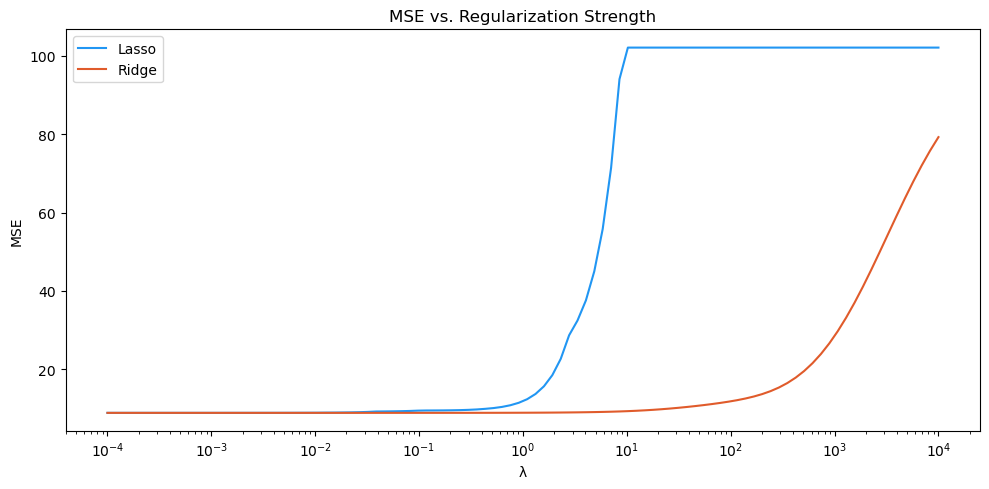

In [ ]:
# Visualize lambdas against MSE for Lasso and Ridge
mse_lasso = []
mse_ridge = []

for lam in lambdas: 
    lasso = Lasso(alpha = lam)
    ridge = Ridge(alpha = lam)

    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    # Evaluate on test set
    mse_lasso.append(
        # MSE
        mean_squared_error(y_test, 
                                        # Predictions
                                        lasso.predict(X_test_scaled)))
    mse_ridge.append(
        # MSE
        mean_squared_error(y_test, 
                                        # Predictions
                                        ridge.predict(X_test_scaled)))


    

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color='blue')
plt.plot(lambdas, mse_ridge, label='Ridge', color='red')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()


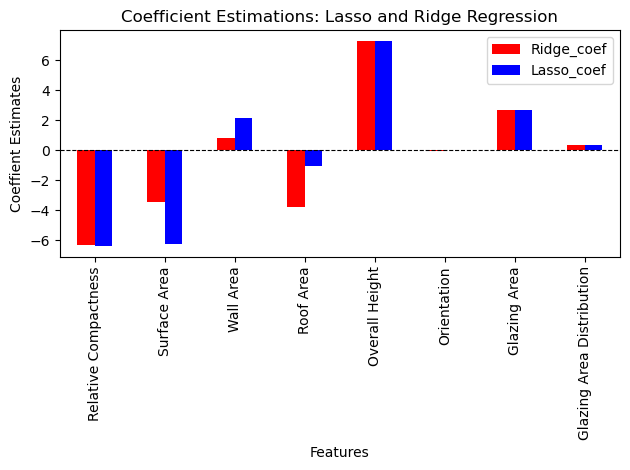

In [29]:
coeffients = pd.DataFrame({
    'Ridge_coef': ridge_cv.coef_,
    'Lasso_coef': lasso_cv.coef_
}, index=feature_names)

# Plot 
ax = coeffients.plot(kind = 'bar', color = ['red', 'blue'], title = "Coefficient Estimations: Lasso and Ridge Regression")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel("Coeffient Estimates")
ax.set_xlabel('Features')
#ax.set_xticklabels(coeffients.index, rotation=45)

plt.tight_layout()
plt.show()

> **Q4: Which model would you pick for this dataset? Why?**

The MSE for all regression models are very similar, with lasso reducing from the ridge MSE by only 0.00239. Lasso more harshly zeroed out orientation and glazing area distribution, which is helpful for feature selection. However, since there are quite a few predictors in these models, and Ridge provides a more even response, I would select this as it is unlikely to discard potentially important variables. 

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [58]:
pca_full = PCA(n_components=8).fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)


In [72]:
pca_table = pd.DataFrame({
    'Component': list(range(1,9)),
    'Explained Variance': explained_var, 
    'Cumulative Variance': cumulative_var
})
pca_table

,Component,Explained Variance,Cumulative Variance
0,1,4.629048e-01,0.462905
1,2,1.563182e-01,0.619223
2,3,1.497484e-01,0.768971
3,4,1.243148e-01,0.893286
4,5,9.966322e-02,0.992949
5,6,6.477268e-03,0.999427
6,7,5.733790e-04,1.000000
7,8,3.255620e-33,1.000000


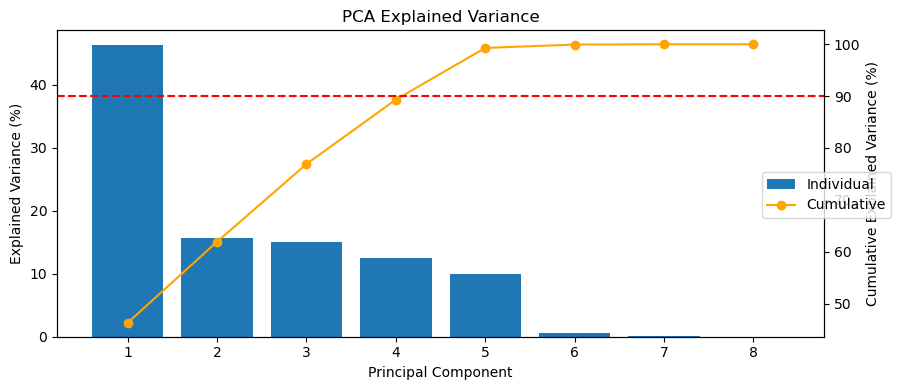

In [60]:
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.bar(range(1, len(explained_var) + 1), pca_full.explained_variance_ratio_ * 100, label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, color='orange', marker='o', label='Cumulative')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.axhline(90, color='red', linestyle='--')

plt.title('PCA Explained Variance')
fig.legend(loc='center right')
plt.tight_layout()
plt.show()

In [61]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It took 4 principle components to explain 89% of variance in all features, and 5 to reach 99% of variance in features. 

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [101]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above

best_k = int(pca_table[pca_table['Cumulative Variance'] >= 0.9].iloc[0]['Component'])

pca_final = PCA(n_components = best_k ).fit(X_train_scaled)

X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

ols_pcr = LinearRegression().fit(X_train_pca, y_train)

y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)



<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

Although K = 4 represents about 90% of the variance, I chose K = 5 is as it explains over 90% of the variance in the features. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [108]:
summary_table = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso', 'PCA'],
    'MSE': [mse_ols, 
            mse_rcv, 
            mse_lcv, 
            mse_pcr]
})
summary_table

,Model,MSE
0,OLS,8.839503
1,Ridge,8.843961
2,Lasso,8.841571
3,PCA,12.703310


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

Linear regression has the smallest MSE, with ridge and lasso being marginally higher. PCA has a noteably large MSE because it dropped three predictors, which indicates it being a bad model for the data. PCA is also not a great option as we do not know for certain that the predictors with the most variation are also most predictive. 

As the linear models do not show a response in decreasing the MSE with ridge or lasso, the simple linear model is performing best, suggesting that data doesn't require regularization. 

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [109]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!